# $$ \textbf{Sinais e Sistemas Dinâmicos}$$

## Sinais e Sistemas - Aulas 07 e 12 de Agosto de 2024 - Exercícios de Revisão



In [3]:
## Importação das bibliotecas Python, como indicado no texto ##

# biblioteca Python para matemática simbólica 
import sympy as sym
from sympy import * 

# Pacote para computação científica
import numpy as np

# biblioteca para a visualização de dados em Python.
import matplotlib.pyplot as plt

# Este módulo fornece acesso às funções matemáticas (definidas pelo padrão C)
import math

# cmath permite operações com números complexos
import cmath

# O módulo de frações fornece suporte para aritmética de números racionais
from fractions import Fraction

# permite usar latex para exibir equações matemáticas no Jupyter Notebook
from IPython.display import display, Math

## Exercícios

#### 1. Determine as medidas adequadas dos sinais na figura abaixo.


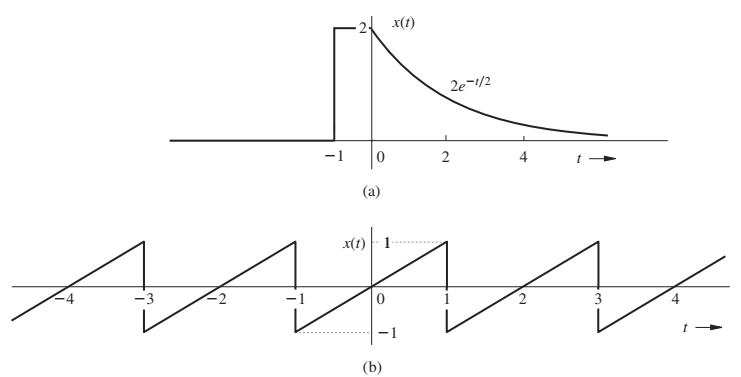

In [4]:
t = symbols('t')
E = integrate(2**2,(t,-1,0)) + integrate((2*exp(-t/2))**2,(t,0,oo))
display(Math('a) \quad E_{x} = %g ' %(E)))

<IPython.core.display.Math object>

In [5]:
t = symbols('t')
P = integrate(t**2,(t,-1,1))/2
display(Math('b) \quad P_{x} = %s ' %(P)))

<IPython.core.display.Math object>

#### 2. Determine a potência e o valor rms de

(a) $x(t)=C \cos \left(\omega_0 t+\theta\right)$


**Solução**: A potência é dada por:

In [91]:
C, t, w0, th = symbols('C t w0 th', real = True, positive  = True)
P1 = simplify((integrate((C*cos(w0*t + th))**2,(t,0,2*pi/w0))*w0/(2*pi)))
P1

C**2/2

$$
P_x = \frac{C^2}{2}
$$

O valor rms (raiz média quadrática) de x(t) é dado por

$$
rms_x = \frac{\sqrt{2 }|C|}{2}
$$

(b) $x(t)=C_1 \cos \left(\omega_1 t+\theta_1\right)+C_2 \cos \left(\omega_2 t+\theta_2\right)$ $\omega_1 \neq \omega_2$

**Solução**: A potência é dada por:

In [104]:
C1, C2, t, w1, w2, th1, th2, T = symbols('C1 C2 t w1 w2 th1 th2 T', real = True, nonzero = True)

aux = (C1*cos(w1*t + th1) + C2*cos(w2*t + th2))**2
expand(aux)

C1**2*cos(t*w1 + th1)**2 + 2*C1*C2*cos(t*w1 + th1)*cos(t*w2 + th2) + C2**2*cos(t*w2 + th2)**2

Vamos resolver cada parte do integrando separadamente $P_2 = P_{2a} + P_{2b} + P_{2c}$, onde 
$$
\begin{aligned}
P_{2a} &= \lim_{T \rightarrow \infty} \frac{1}{2T} \int_{-T}^{T }  C_1^2 \cos ^2\left(\omega_1 t+\theta_1 \right) d t \\
P_{2b} &= \lim_{T \rightarrow \infty} \frac{1}{2T} \int_{-T}^{T }  C_2^2 \cos ^2\left(\omega_2 t+\theta_2 \right) d t \\
P_{2c} &= \lim_{T \rightarrow \infty} \frac{1}{2T} \int_{-T}^{T }  2C_1C_2 \cos\left(\omega_1 t+\theta_1 \right)\cos\left(\omega_2 t+\theta_2 \right) d t 
\end{aligned}
$$


Temos que

In [105]:
P2a = limit(integrate((C1*cos(w1*t + th1))**2,(t,-T,T))/(2*T),T,oo)
simplify(P2a)

C1**2/2

$$
P_{2a} = \frac{C_1^2}{2}
$$
Assim, analogamente, temos que 
$$
P_{2b} = \frac{C_2^2}{2}
$$

Finalmente, temos que

In [114]:
w1, w2 = symbols('w1 w2', real = True, positive = True)
Ne(w2 - w1,0)
P2c = integrate(2*C1*C2*cos(w1*t + th1)*cos(w2*t + th2),(t,-T,T))/(2*T)
simplify(P2c)

Piecewise((C1*C2*(w1*sin(T*w1 - th1)*cos(T*w2 - th2) + w1*sin(T*w1 + th1)*cos(T*w2 + th2) - w2*sin(T*w2 - th2)*cos(T*w1 - th1) - w2*sin(T*w2 + th2)*cos(T*w1 + th1))/(T*(w1**2 - w2**2)), Ne(w1, w2)), (C1*C2*(4*T*w2*cos(th1 - th2) - sin(-2*T*w2 + th1 + th2) + sin(2*T*w2 + th1 + th2))/(4*T*w2), True))

Se $w1 \neq w2$, podemos multiplicar o resultado por $(w_1^2 - w_2^2)$ e obter

In [127]:
limit(C1*C2*(w1*sin(T*w1-th1)*cos(T*w2-th2)+w1*sin(T*w1+th1)*cos(T*w2+th2)-w2*sin(T*w2-th2)*cos(T*w1-th1)-w2*sin(T*w2+th2)*cos(T*w1+th1))/T,T,oo)

0

Se $w1 = w2$,

In [116]:
limit(C1*C2*(4*T*w2*cos(th1 - th2) - sin(-2*T*w2 + th1 + th2) + sin(2*T*w2 + th1 + th2))/(4*T*w2),T,oo)

C1*C2*cos(th1 - th2)

Como estamos supondo que $w1 \neq w2$, obtemos
$$
P_2=\frac{C_1{ }^2}{2}+\frac{C_2{ }^2}{2}
$$

(c) $x(t)=D e^{j \omega_0 t}$

In [130]:
D, w0 = symbols('D w0', real = True)
P = limit(integrate(D*exp(1J*w0*t)*conjugate(D*exp(1J*w0*t)),(t,-T,T))/(2*T),T,oo)
P

D**2

#### 3. Mostre que as energias dos sinais da Fig. 1.3a, 1.3 b, 1.3 c e 1.3 d são $4,1,4 / 3$ e $4 / 3$, respectivamente. Observe que o dobro do sinal quadruplica sua energia e o deslocamento no tempo de um sinal não possui efeito em sua energia. Mostre também que a potência do sinal da Fig. 1.3e é 0,4323 . Qual é o valor rms do sinal da Fig. 1.3e?

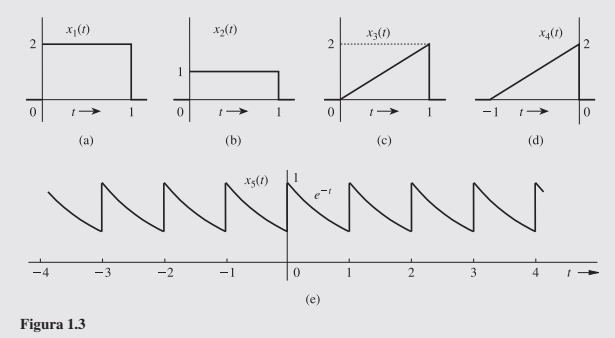

#### 4. Refaça o Exemplo 1.2a para determinar a potência da senóide $C \cos \left(\omega_0 t+\theta\right)$ calculando a média da energia do sinal em um período $T_0=2 \pi \omega_0$ (em vez de calcular a média em um intervalo infinitamente grande de tempo). Mostre também que a potência de um sinal $\mathrm{CC} x(t)=C_0$ é $C_0^2$ e seu valor rms é $C_0$.

#### 5. Mostre que se $\omega_1=\omega_2$, a potência de $C_1 \cos \left(\omega_1 t+\theta_1\right)+C_2 \cos \left(\omega_2 t+\theta_2\right)$ é $\left[C_1^2+C_2^2+2 C_1 C_2 \cos \left(\theta_1-\theta_2\right)\right] / 2$, o qual não é igual a $\left(C_1^2+C_2^2\right) / 2$.

#### 6. A função exponencial $x(t)=e^{-2 t}$ mostrada na Fig. 1.5a é atrasada por 1 segundo. Trace e descreva matematicamente a função atrasada. Repita o problema $\operatorname{com} x(t)$ adiantado por 1 segundo.

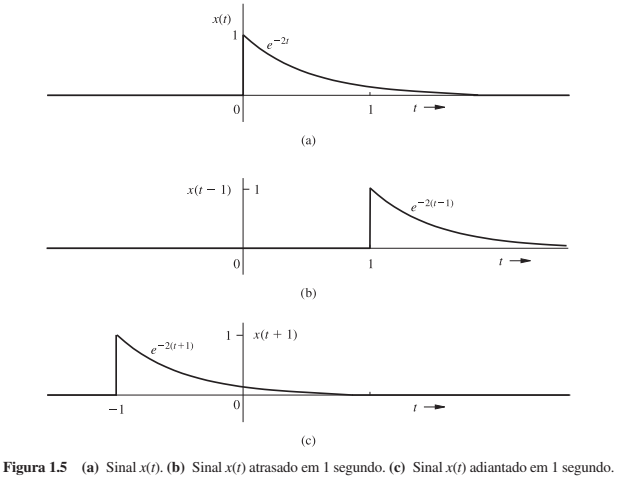

#### 7. A Fig. 1.7a mostra um sinal $x(t)$. Trace e descreva matematicamente este sinal comprimido no tempo por um fator 3. Repita o problema para o mesmo sinal expandido no tempo por um fator 2.

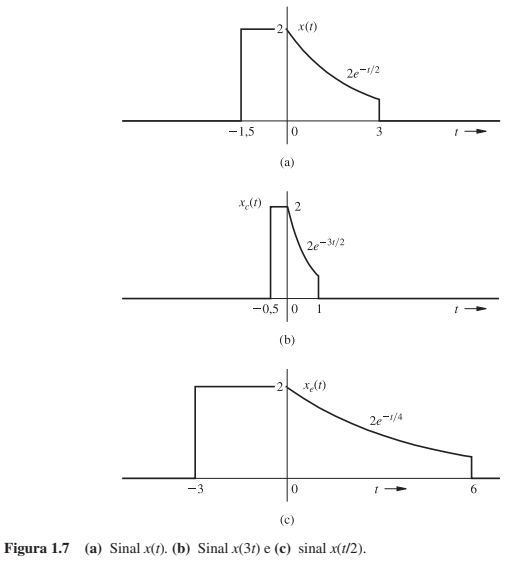

#### 8. Para o sinal $x(t)$ mostrado na Fig. 1.9a, trace $x(-t)$, o qual é a reversão temporal de $x(t)$.


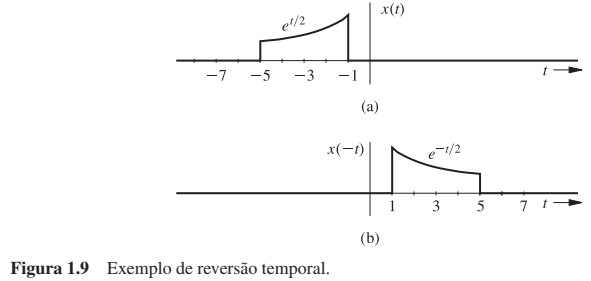

#### 9. Mostre que

(a) $\left(t^3+3\right) \delta(t)=3 \delta(t)$

(b) $\left[\operatorname{sen}\left(t^2-\frac{\pi}{2}\right)\right] \delta(t)=-\delta(t)$

(c) $e^{-2 t} \delta(t)=\delta(t)$

(d) $\frac{\omega^2+1}{\omega^2+9} \delta(\omega-1)=\frac{1}{5} \delta(\omega-1)$

#### 10. Mostre que

(a) $\int_{-\infty}^{\infty} \delta(t) e^{-j \omega t} d t=1$

(b) $\int_{-\infty}^{\infty} \delta(t-2) \cos \left(\frac{\pi t}{4}\right) d t=0$

(c) $\int_{-\infty}^{\infty} e^{-2(x-t)} \delta(2-t) d t=e^{-2(x-2)}$

#### 11. Mostre que um sistema com entrada $x(t)$ e saída $y(t)$ relacionadas por $y(t)=\operatorname{Re}\{x(t)\}$ satisfaz a propriedade de aditividade mas viola a propriedade de homogeneidade. Logo, tal sistema é não linear. [Dica: Mostre que a Eq. (1.39) não é satisfeita quando $k$ é complexo.]

#### 12. Mostre que o sistema descrito pela equação
$$
\frac{d y}{d t}+3 y(t)=x(t)
$$
é linear.

#### 13. Mostre que o sistema descrito pela seguinte equação não é linear:
$$
y(t) \frac{d y}{d t}+3 y(t)=x(t)
$$

#### 14. Mostre que um sistema descrito pela seguinte equação é um sistema com parâmetros variantes no tempo:
$$
y(t)=(\operatorname{sen} t) x(t-2)
$$

#### 15. Um sistema em tempo contínuo é dado por
$$
y(t)=0,5 \int_{-\infty}^{\infty} x(\tau)[\delta(t-\tau)-\delta(t+\tau)] d \tau
$$

Lembre-se que $\delta(t)$ representa a função delta de Dirac.

(a) Explique o que este sistema faz.

(b) O sistema é estável BIBO? Justifique sua resposta.

(c) O sistema é linear? Justifique sua resposta.

#### 16. Para um sistema LCIT com resposta ao impulso unitário dada por $h(t)=e^{-2 t} u(t)$. determine a resposta $y(t)$ para a entrada
$$
x(t)=e^{-t} u(t)
$$